# Credit Card Customer Churn Analysis

## Business Problem

Generally, acquiring new customers is more expensive than retaining existing ones. The purpose of this analysis is to identify characteristics associated with customer churn and provide actionable insights that may improve customer retention.

## Questions

- What percentage of customers churn?
- Which customer segments have the highest churn?
- Does spending behavior influence churn?
- Which card categories experience the highest attrition?
- Are there differences across age, income, and gender?


In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['text.parse_math'] = False

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/BankChurners.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [5]:
df.shape

(10127, 21)

In [6]:
df.info

<bound method DataFrame.info of        CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      768805383  Existing Customer            45      M                3   
1      818770008  Existing Customer            49      F                5   
2      713982108  Existing Customer            51      M                3   
3      769911858  Existing Customer            40      F                4   
4      709106358  Existing Customer            40      M                3   
...          ...                ...           ...    ...              ...   
10122  772366833  Existing Customer            50      M                2   
10123  710638233  Attrited Customer            41      M                2   
10124  716506083  Attrited Customer            44      F                1   
10125  717406983  Attrited Customer            30      M                2   
10126  714337233  Attrited Customer            43      F                2   

      Education_Level Marital_Status Income

In [7]:
df.describe

<bound method NDFrame.describe of        CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      768805383  Existing Customer            45      M                3   
1      818770008  Existing Customer            49      F                5   
2      713982108  Existing Customer            51      M                3   
3      769911858  Existing Customer            40      F                4   
4      709106358  Existing Customer            40      M                3   
...          ...                ...           ...    ...              ...   
10122  772366833  Existing Customer            50      M                2   
10123  710638233  Attrited Customer            41      M                2   
10124  716506083  Attrited Customer            44      F                1   
10125  717406983  Attrited Customer            30      M                2   
10126  714337233  Attrited Customer            43      F                2   

      Education_Level Marital_Status Inco

In [8]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [11]:
churn_rate = (df['Attrition_Flag'].value_counts(normalize=True)*100).round(2)

churn_rate

Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64

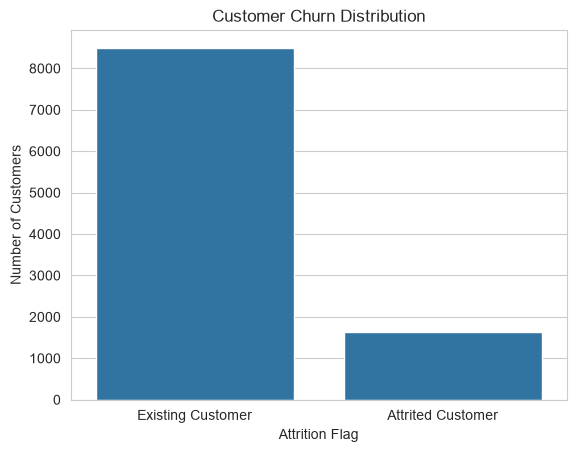

In [12]:
sns.countplot(data=df, x='Attrition_Flag')

plt.title('Customer Churn Distribution')
plt.xlabel('Attrition Flag')
plt.ylabel('Number of Customers')

plt.show()

Approximately 16% of customers have attrited, while 84% remain active.

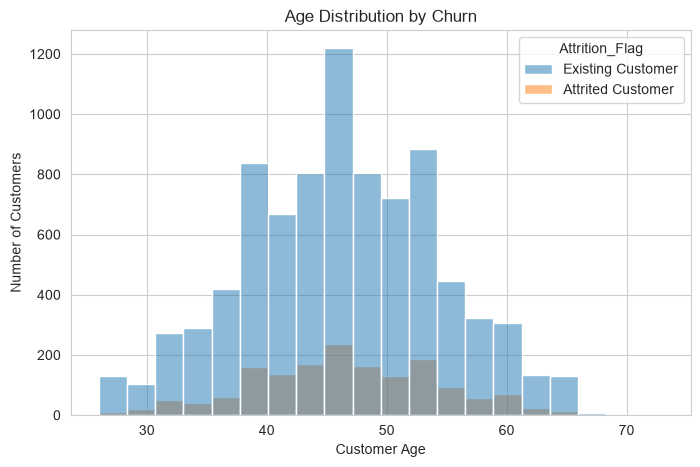

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Customer_Age', hue='Attrition_Flag', bins=20)

plt.title('Age Distribution by Churn')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')

plt.show()

Customers aged between 40 and 50 appear to exhibit higher attrition rates.

In [14]:
pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index')

Attrition_Flag,Attrited Customer,Existing Customer
Gender,,
F,0.173572,0.826428
M,0.146152,0.853848


Females customers seem to appear to experience slightly higher attrition.

In [15]:
card_churn = pd.crosstab(df['Card_Category'], df['Attrition_Flag'], normalize='index').round(4) * 100

card_churn

Attrition_Flag,Attrited Customer,Existing Customer
Card_Category,,
Blue,16.10,83.90
Gold,18.10,81.90
Platinum,25.00,75.00
Silver,14.77,85.23


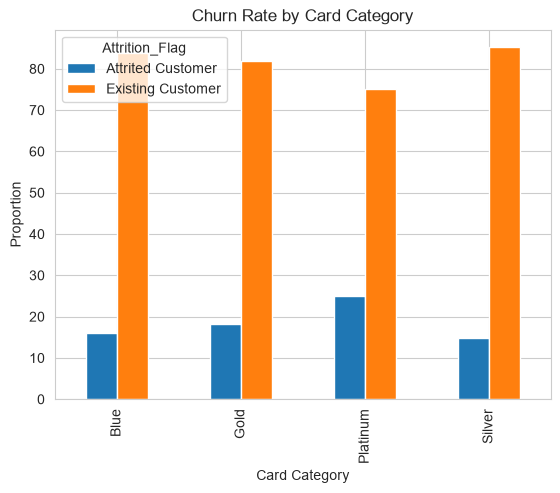

In [16]:
card_churn.plot(kind='bar')

plt.xlabel('Card Category')
plt.ylabel('Proportion')
plt.title('Churn Rate by Card Category')
plt.show()

In [17]:
card_churn = pd.crosstab(
    df['Card_Category'],
    df['Attrition_Flag']
)

card_churn['% of Total Churned Customers'] = (
    card_churn['Attrited Customer']
    / card_churn['Attrited Customer'].sum()
    * 100
).round(2)


card_churn

Attrition_Flag,Attrited Customer,Existing Customer,% of Total Churned Customers
Card_Category,,,
Blue,1519,7917,93.36
Gold,21,95,1.29
Platinum,5,15,0.31
Silver,82,473,5.04


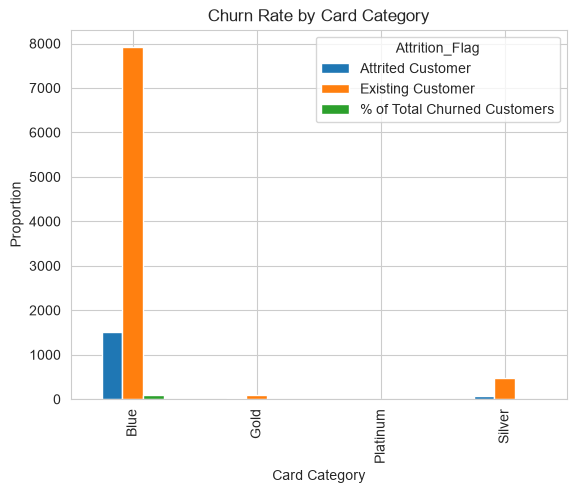

In [18]:
card_churn.plot(kind='bar')

plt.xlabel('Card Category')
plt.ylabel('Proportion')
plt.title('Churn Rate by Card Category')
plt.show()

Platinum card holders exhibit the highest churn rate by card category, however it contains the least amount of customers by far, blue card holders consist of an overwhelming majority of 93% of churned customers.

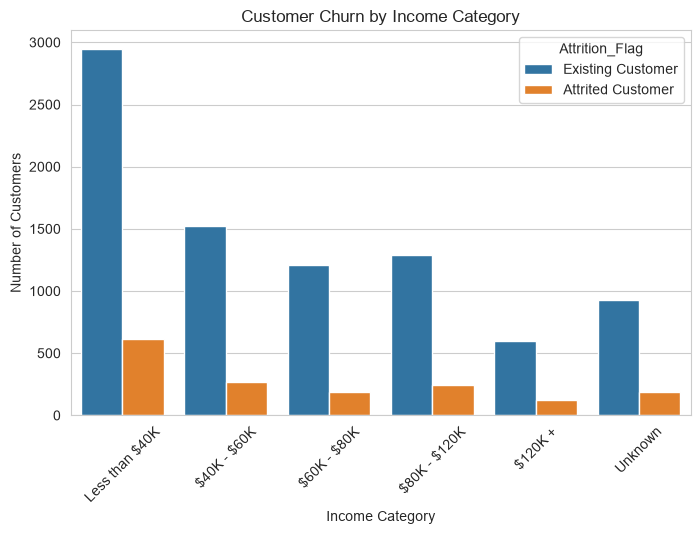

In [19]:
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag', order=income_order)

plt.xticks(rotation=45)
plt.title('Customer Churn by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Number of Customers')

plt.show()

In [20]:
income_churn = pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index')

income_churn = (income_churn * 100).round(2).reindex(income_order)

income_churn['% of Total Churned Customers'] = (df['Income_Category'].value_counts(normalize=True) * 100).round(2)
display_income = income_churn.copy()

display_income.index = display_income.index.str.replace(
    "$", r"\$", regex=False
)

display(display_income)

Attrition_Flag,Attrited Customer,Existing Customer,% of Total Churned Customers
Income_Category,,,
Less than \$40K,17.19,82.81,35.16
\$40K - \$60K,15.14,84.86,17.68
\$60K - \$80K,13.48,86.52,13.84
\$80K - \$120K,15.77,84.23,15.16
\$120K +,17.33,82.67,7.18
Unknown,16.82,83.18,10.98


It appears that the highest income customers of \\$120k+ have the highest churn rate, and the lowest income customers of less than \\$40k have the second highest churn rate. However like before, customers with less than \\$40K compose of the highest percentage of churned customers.

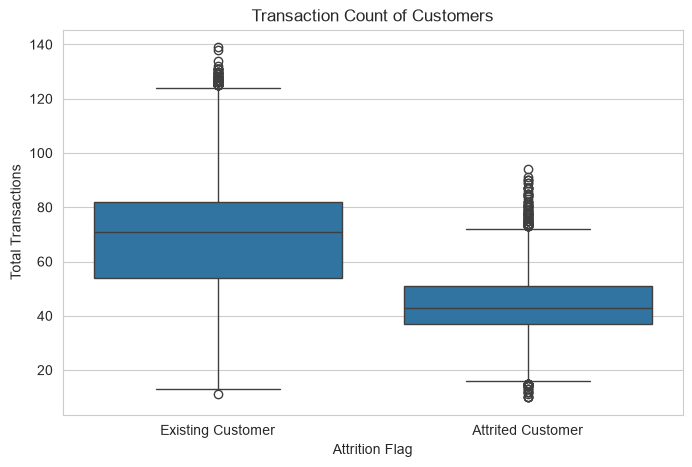

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct')

plt.title('Transaction Count of Customers')
plt.ylabel('Total Transactions')
plt.xlabel('Attrition Flag')
plt.show()

Customers who churn exibit substantially lower transaction counts.

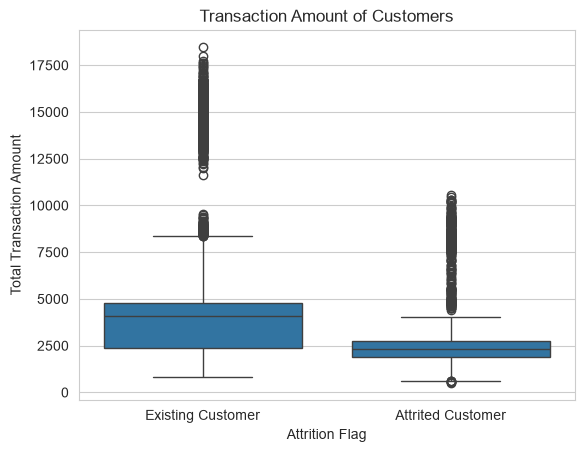

In [22]:
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Amt')

plt.title('Transaction Amount of Customers')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Amount')
plt.show()

Churned customers appear to generally spend less than existing customers.

## Key Findings

1. Approximately 16% of customers have churned.
2. Customers with high income and customers with low income are the most likely to churn.
3. Customers with fewer transactions and lower spending levels are more likely to churn.
4. Gender may have a minor association with churn, but it is unlikely to be a primary driver of customer attrition.
5. While Platinum card holders exhibit the highest churn rate and high income customers have a high churn rate, Blue card holders and low income customers compose of the vast majority of customers and churned customers.

## Recommendations
- Identify customers with low transaction counts and spending levels and implement early-warning retention campaigns since reduced card activity is strongly accociated with churning
- Develop targeted retention strategies for Blue card holders
- Create segmented retention strategies based on income level
- Monitor high-value customer segments, including Platinum card holders, despite their small population, as their elevated churn rate may indicate opportunities to improve premium customer retention.